# Deep Ensembles for a Parametric 1D Poisson Problem

This notebook uses **deep ensembles** as a regression-first uncertainty baseline
for a simple scientific surrogate. The governing equation is

$$
-u''(x)=f(x;a,b,c),\quad x\in[0,1],\qquad u(0)=u(1)=0,
$$

with forcing

$$
f(x;a,b,c)=a\sin(\pi x)+b\sin(3\pi x)+c\sin(7\pi x).
$$

The exact solution is known analytically, which makes it easy to evaluate both
fit error and uncertainty quality.

**Input to the model:** the coordinate $x$ and source parameters $(a,b,c)$.

**Output of the model:** the scalar solution value $u(x)$.

Primary paper:

- Lakshminarayanan, Pritzel, Blundell (2017), *Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles*.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import DeepEnsembleWrapper
from deepuq.models import MLP

plt.rcParams['figure.figsize'] = (8, 4)
torch.manual_seed(7)
np.random.seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## Dataset and physical meaning

This is a steady-state diffusion / elasticity style problem. The source term
$f(x;a,b,c)$ acts like a distributed load, and the solution $u(x)$ is the static
response. By varying $(a,b,c)$, we define a family of PDEs and learn the mapping
from parameters plus coordinate to the corresponding solution value.

The training distribution uses only the **low-frequency forcing family** with
$c=0$. The in-domain test split is sampled from a **central interpolation region**
of the training parameter box, so it represents easy, well-supported cases. The
OOD split activates the **unseen high-frequency mode** $\sin(7\pi x)$ through
$c>0$ and also shifts $(a,b)$ toward stronger loads. This combination makes OOD
samples structurally harder and should increase ensemble disagreement.


## What OOD means in this notebook

This notebook uses **OOD in parameter space**, not lack of observations in physical space.

- **Training / validation data** uses low-frequency forcing with $(a,b)$ spread over the main training box and $c=0$.
- **In-domain test data** uses a tighter central subset of that same box, again with $c=0$.
- **OOD data** moves toward stronger forcing and turns on an unseen high-frequency coefficient $c>0$.

That means the intended uncertainty story is:

- low predictive uncertainty for **central interpolation cases**,
- larger predictive uncertainty for **unseen forcing regimes**,
- not necessarily larger uncertainty at one special location $x$ inside the domain.

If you want uncertainty to peak in a specific weak-data region of physical space, use a notebook with **spatially missing information**, such as the 1D DeepONet Poisson example with a sensor gap. This deep-ensemble example is instead about **distribution shift in PDE parameters and frequency content**.


In [2]:
config = {
    'n_train': 240,
    'n_val': 60,
    'n_test': 60,
    'n_ood': 60,
    'n_x': 64,
    'ensemble_size': 5,
    'epochs': 80,
    'batch_size': 512,
    'lr': 2e-3,
}


def exact_solution(x, a, b, c):
    return (
        (a / math.pi**2) * torch.sin(math.pi * x)
        + (b / (9.0 * math.pi**2)) * torch.sin(3.0 * math.pi * x)
        + (c / (49.0 * math.pi**2)) * torch.sin(7.0 * math.pi * x)
    )


def sample_params(n, split='train'):
    if split in {'train', 'val'}:
        a = 0.5 + torch.rand(n, 1)
        b = -0.2 + 0.4 * torch.rand(n, 1)
        c = torch.zeros(n, 1)
    elif split == 'test':
        a = 0.9 + 0.2 * torch.rand(n, 1)
        b = -0.05 + 0.1 * torch.rand(n, 1)
        c = torch.zeros(n, 1)
    elif split == 'ood':
        a = 1.3 + 0.5 * torch.rand(n, 1)
        b = 0.15 + 0.35 * torch.rand(n, 1)
        c = 2.0 + 1.0 * torch.rand(n, 1)
    else:
        raise ValueError(f'unknown split: {split}')
    return a, b, c


def build_point_dataset(n_samples, *, split='train'):
    x = torch.linspace(0.0, 1.0, config['n_x']).unsqueeze(-1)
    a, b, c = sample_params(n_samples, split=split)
    x_grid = x.unsqueeze(0).repeat(n_samples, 1, 1)
    a_grid = a.unsqueeze(1).repeat(1, config['n_x'], 1)
    b_grid = b.unsqueeze(1).repeat(1, config['n_x'], 1)
    c_grid = c.unsqueeze(1).repeat(1, config['n_x'], 1)
    y = exact_solution(x_grid, a_grid, b_grid, c_grid)
    features = torch.cat([x_grid, a_grid, b_grid, c_grid], dim=-1)
    return features.reshape(-1, 4), y.reshape(-1, 1), x.squeeze(-1), (a, b, c)


train_x, train_y, x_axis, train_params = build_point_dataset(config['n_train'], split='train')
val_x, val_y, _, _ = build_point_dataset(config['n_val'], split='val')
test_x, test_y, _, test_params = build_point_dataset(config['n_test'], split='test')
ood_x, ood_y, _, ood_params = build_point_dataset(config['n_ood'], split='ood')

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(TensorDataset(val_x, val_y), batch_size=config['batch_size'])


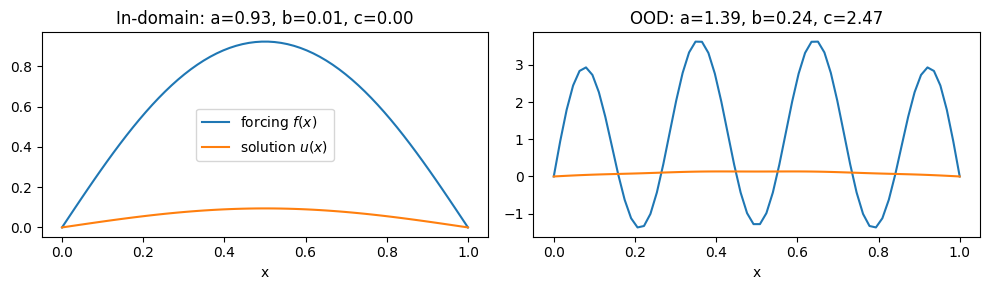

In [3]:
# Visualize one in-domain and one OOD forcing/solution pair.
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, params, title in zip(axes, [test_params, ood_params], ['In-domain', 'OOD']):
    a = params[0][0].item()
    b = params[1][0].item()
    c = params[2][0].item()
    forcing = a * torch.sin(math.pi * x_axis) + b * torch.sin(3.0 * math.pi * x_axis) + c * torch.sin(7.0 * math.pi * x_axis)
    solution = exact_solution(
        x_axis.unsqueeze(-1),
        torch.tensor([[a]]),
        torch.tensor([[b]]),
        torch.tensor([[c]]),
    ).squeeze(-1)
    ax.plot(x_axis, forcing, label='forcing $f(x)$')
    ax.plot(x_axis, solution, label='solution $u(x)$')
    ax.set_title(f'{title}: a={a:.2f}, b={b:.2f}, c={c:.2f}')
    ax.set_xlabel('x')
axes[0].legend()
plt.tight_layout()
plt.show()


## Train the ensemble

Each member is an independent `MLP`. The ensemble mean is the prediction, and
the spread between members is the epistemic uncertainty estimate.


In [4]:
models = [MLP(4, [128, 128, 128], 1, p_drop=0.0).to(device) for _ in range(config['ensemble_size'])]
ensemble = DeepEnsembleWrapper(models).to(device)
ensemble.fit(
    train_loader,
    epochs=config['epochs'],
    loss_fn=torch.nn.functional.mse_loss,
    lr=config['lr'],
    weight_decay=1e-4,
    device=device,
    seed=13,
)


DeepEnsembleWrapper(
  (models): ModuleList(
    (0-4): 5 x MLP(
      (net): Sequential(
        (0): Linear(in_features=4, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.0, inplace=False)
        (3): Linear(in_features=128, out_features=128, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.0, inplace=False)
        (6): Linear(in_features=128, out_features=128, bias=True)
        (7): ReLU()
        (8): Dropout(p=0.0, inplace=False)
        (9): Linear(in_features=128, out_features=1, bias=True)
      )
    )
  )
)

In [5]:
@torch.inference_mode()
def evaluate_dataset(x, y):
    mean, var = ensemble.predict(x.to(device))
    rmse = torch.mean((mean.cpu() - y) ** 2).sqrt().item()
    mean_std = var.cpu().sqrt().mean().item()
    return mean.cpu(), var.cpu(), rmse, mean_std

mean_test, var_test, rmse_test, std_test = evaluate_dataset(test_x, test_y)
mean_ood, var_ood, rmse_ood, std_ood = evaluate_dataset(ood_x, ood_y)
print({
    'test_rmse': rmse_test,
    'ood_rmse': rmse_ood,
    'test_mean_predictive_std': std_test,
    'ood_mean_predictive_std': std_ood,
})

assert std_ood > std_test, (
    'Expected OOD predictive std to exceed test predictive std for this notebook. '
    'If this fails after a clean rerun, inspect the parameter split or stale outputs.'
)


{'test_rmse': 0.0014831193257123232, 'ood_rmse': 0.012193731032311916, 'test_mean_predictive_std': 0.0010733908275142312, 'ood_mean_predictive_std': 0.0016862867632880807}


## Reading the uncertainty summary

This notebook is designed so the **OOD mean predictive standard deviation is larger than the in-domain test mean predictive standard deviation**. The reason is structural, not just numerical: training only sees the low-frequency forcing family with $c=0$, while the OOD split activates an unseen high-frequency mode and stronger load amplitudes. So the intended story is **larger ensemble spread on unseen PDE families in parameter space**.


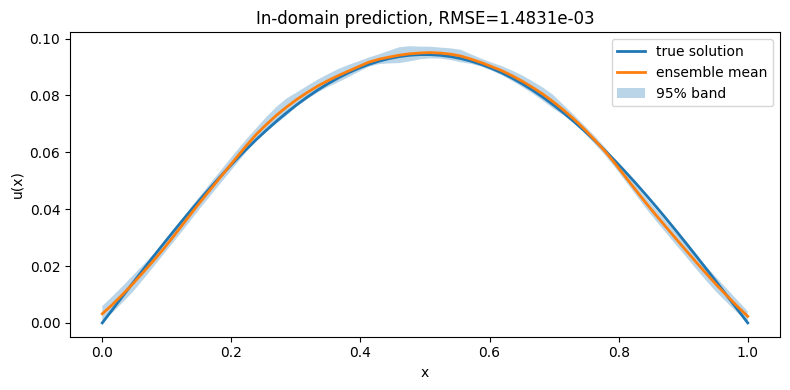

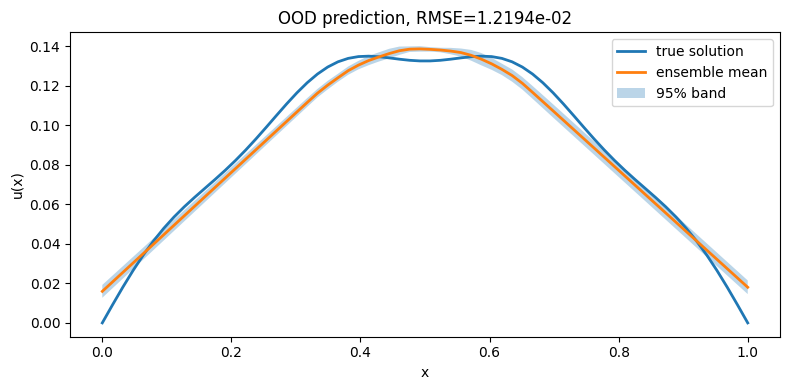

In [6]:
# Plot predictive bands for a representative in-domain and OOD parameter set.

def plot_band(features, targets, mean, var, title):
    n = config['n_x']
    idx = 0
    x = features[idx * n:(idx + 1) * n, 0]
    y_true = targets[idx * n:(idx + 1) * n, 0]
    y_mean = mean[idx * n:(idx + 1) * n, 0]
    y_std = var[idx * n:(idx + 1) * n, 0].sqrt()
    plt.figure(figsize=(8, 4))
    plt.plot(x, y_true, label='true solution', linewidth=2)
    plt.plot(x, y_mean, label='ensemble mean', linewidth=2)
    plt.fill_between(x.numpy(), (y_mean - 2 * y_std).numpy(), (y_mean + 2 * y_std).numpy(), alpha=0.3, label='95% band')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_band(test_x, test_y, mean_test, var_test, f'In-domain prediction, RMSE={rmse_test:.4e}')
plot_band(ood_x, ood_y, mean_ood, var_ood, f'OOD prediction, RMSE={rmse_ood:.4e}')


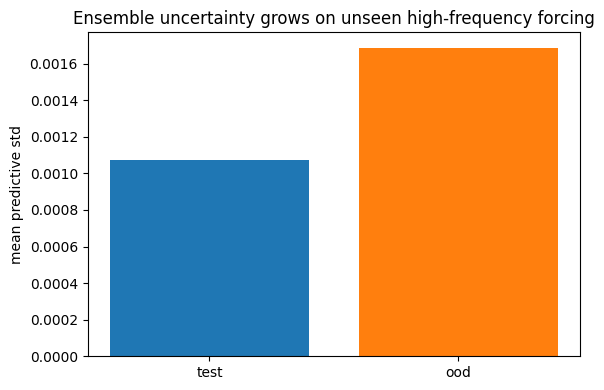

In [7]:
# Compare average uncertainty levels on in-domain and OOD sets.
plt.figure(figsize=(6, 4))
plt.bar(['test', 'ood'], [std_test, std_ood], color=['tab:blue', 'tab:orange'])
plt.ylabel('mean predictive std')
plt.title('Ensemble uncertainty grows on unseen high-frequency forcing')
plt.tight_layout()
plt.show()
